In [18]:
import numpy as np
from suncalc import get_position
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely import coverage_union_all
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from zoneinfo import ZoneInfo
from precompute_shadows import calculate_shadow
from datetime import datetime
import math

### Combine trees info with buildings

In [6]:
trees = gpd.read_file("trees_ovgu.fgb")

In [10]:
trees = trees.rename(columns={"height_m": "height"})
output_file = "trees_ovgu.fgb"
trees.to_file(output_file, driver="FlatGeobuf")

In [14]:
trees_4326 = trees.copy()
trees_4326 = trees_4326.to_crs(4326)

In [15]:
trees_4326.to_file("trees_ovgu_4326.fgb", driver="FlatGeobuf")

In [26]:
lat_min = 52.137663
lat_max = 52.145538
lon_min = 11.639779
lon_max = 11.652739
ovgu_bbox = (lon_min, lat_min, lon_max, lat_max)

buildings_ovgu = gpd.read_file("./data/buildings.fgb", bbox=ovgu_bbox)

In [27]:
# Select and rename relevant columns
buildings_clean = buildings_ovgu[["original_building_id", "height", "geometry"]].rename(
    columns={"original_building_id": "id"}
)

trees_clean = trees_4326[["tree_id", "height", "geometry"]].rename(
    columns={"tree_id": "id"}
)

# Merge into a single GeoDataFrame
merged = gpd.GeoDataFrame(
    pd.concat([buildings_clean, trees_clean], ignore_index=True),
    geometry="geometry",
    crs=buildings_ovgu.crs
)

In [29]:
merged.to_file("merged_buildings_trees.fgb", driver="FlatGeobuf")

In [33]:
import pybdshadow

merged_processed = pybdshadow.bd_preprocess(merged, height="height")
merged_processed

,id,height,geometry,building_id
0,DEST_DESTLIKA0003MHwJ,18.000000,"POLYGON ((11.64033 52.14367, 11.64033 52.14365...",0
1,DEST_DESTLIKA0003MHwJ,18.500000,"POLYGON ((11.64033 52.14367, 11.64034 52.14367...",1
2,DEST_DESTLIKA0003MHBv,4.000000,"POLYGON ((11.64036 52.14341, 11.64035 52.14354...",2
3,DEST_DESTLIKA0003MHBv,2.500000,"POLYGON ((11.64031 52.14354, 11.64032 52.1434,...",3
4,DEST_DESTLIKA0003MHBv,26.500000,"POLYGON ((11.64015 52.14328, 11.64014 52.14341...",4
...,...,...,...,...
2165,52,10.017620,"POLYGON ((11.64124 52.13824, 11.64128 52.13823...",2141
2166,57,4.366145,"POLYGON ((11.64078 52.13796, 11.64079 52.13796...",2142
2167,58,6.594542,"POLYGON ((11.64119 52.13795, 11.6412 52.13795,...",2143
2168,56,8.168310,"POLYGON ((11.6409 52.13797, 11.64092 52.13797,...",2144


In [34]:
merged_processed.to_file("buildings_trees_processed.fgb", driver="FlatGeobuf")

### Test Buildings and Trees

In [ ]:
LAT = 52.13896498167249
LON = 11.645601397328756


In [ ]:
def deg(radians: float) -> float:
    return math.degrees(radians)

In [21]:
BUILDINGS_PATH = "./data/buildings_campus_sp_simplified.fgb"

In [22]:
buildings = gpd.read_file(BUILDINGS_PATH)

In [28]:
current = datetime(2026, 6, 30, 17, 30, tzinfo=ZoneInfo("Europe/Berlin"))

sun_pos = get_position(current, LAT, LON)
alt = deg(float(sun_pos["altitude"]))
az = (deg(float(sun_pos["azimuth"])) + 180) % 360

shadows = calculate_shadow(buildings, az, alt)

In [29]:
def plot_shadows_and_buildings_trees(buildings: gpd.GeoDataFrame, shadows: gpd.GeoDataFrame, dt: pd.Timestamp, whole_day=False):
    fig, ax = plt.subplots(figsize=(12, 12))

    # --- Split buildings and trees by id pattern ---
    is_tree = buildings["id"].astype(str).str.match(r"^\d+$")
    trees_gdf = buildings[is_tree]
    buildings_gdf = buildings[~is_tree]

    # --- Plot shadows ---
    if len(shadows) > 0:
        shadows.plot(ax=ax, color="#555555", alpha=0.4)

    # --- Plot buildings ---
    if len(buildings_gdf) > 0:
        buildings_gdf.plot(ax=ax, color="#3a86ff", alpha=0.8, edgecolor="white", linewidth=0.5)

    # --- Plot trees ---
    if len(trees_gdf) > 0:
        trees_gdf.plot(ax=ax, color="#2dc653", alpha=0.8, edgecolor="white", linewidth=0.5)

    # --- Legend ---
    legend_handles = [
        mpatches.Patch(color="#3a86ff", alpha=0.8, label="Buildings"),
        mpatches.Patch(color="#2dc653", alpha=0.8, label="Trees"),
        mpatches.Patch(color="#555555", alpha=0.4, label="Ground Shadow"),
    ]

    ax.legend(handles=legend_handles, loc="upper right")
    ax.set_title(f"Building Shadow {dt.strftime('%Y-%m-%d %H:%M')}", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

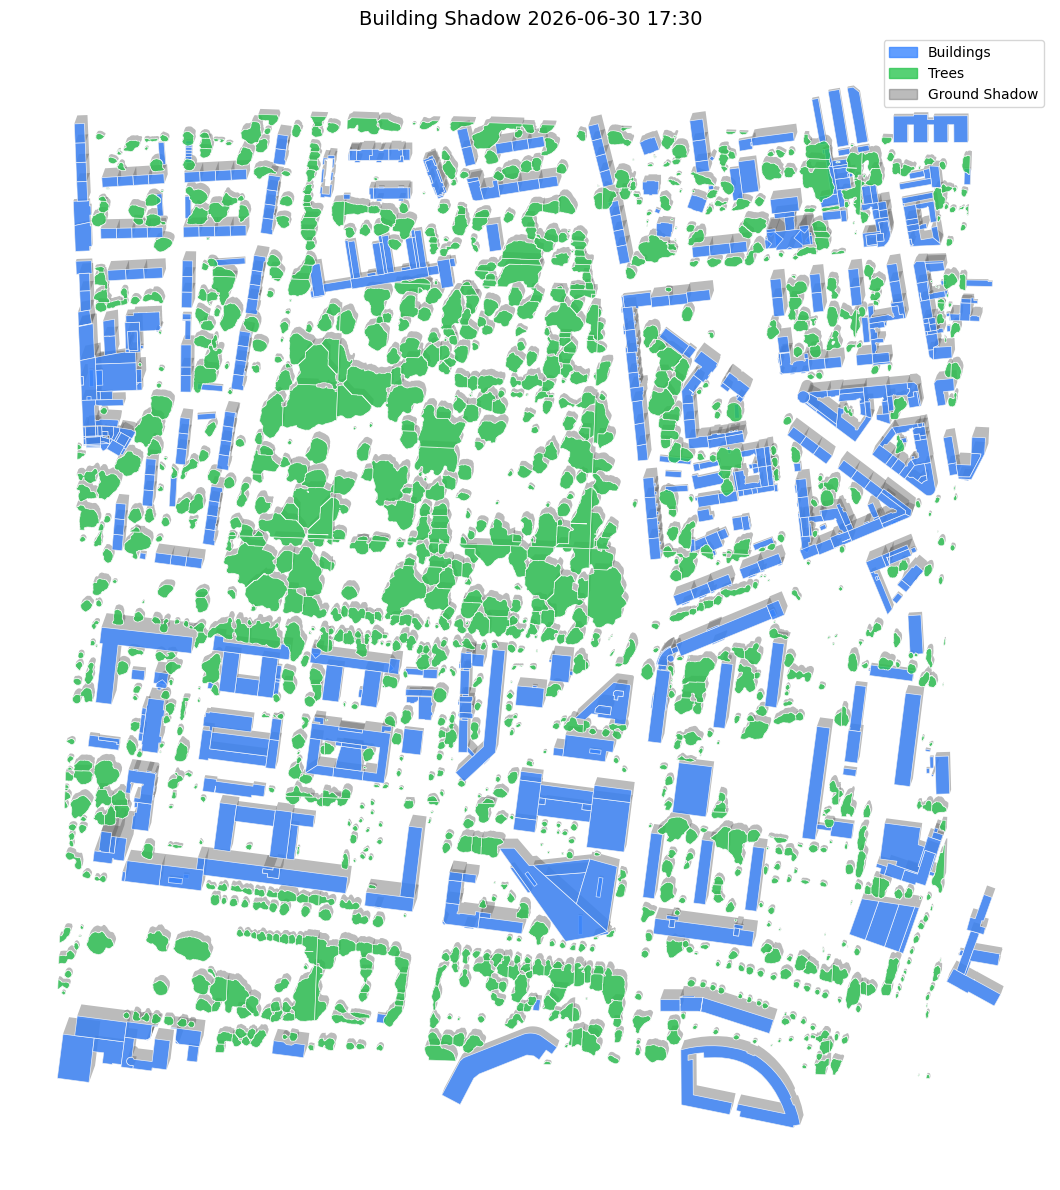

In [30]:
plot_shadows_and_buildings_trees(shadow_service.buildings, shadow_map, current)

In [1]:
import geopandas as gpd

In [2]:
trees = gpd.read_file("./data/trees_ovgu_4326.fgb")

In [3]:
trees

,tree_id,height,crown_radius_m,crown_area_m2,vegetation_model,geometry
0,41,2.897413,2.069580,13.455953,tcd_segformer,"POLYGON ((11.65212 52.13742, 11.65212 52.13742..."
1,42,1.240964,0.886403,2.468381,tcd_segformer,"POLYGON ((11.652 52.13742, 11.652 52.13742, 11..."
2,30,3.365274,2.403767,18.152430,tcd_segformer,"POLYGON ((11.65172 52.1382, 11.65172 52.13819,..."
3,32,2.816317,2.011655,12.713255,tcd_segformer,"POLYGON ((11.65169 52.13812, 11.65169 52.13812..."
4,49,8.715724,6.225517,121.758902,tcd_segformer,"POLYGON ((11.65152 52.13822, 11.65152 52.13822..."
...,...,...,...,...,...,...
1357,52,10.017620,7.155443,160.850694,tcd_segformer,"POLYGON ((11.64124 52.13824, 11.64124 52.13823..."
1358,56,8.168310,5.834507,106.944444,tcd_segformer,"POLYGON ((11.6409 52.13797, 11.6409 52.13797, ..."
1359,57,4.366145,3.118675,30.555556,tcd_segformer,"POLYGON ((11.64078 52.13796, 11.64078 52.13796..."
1360,58,6.594542,4.710387,69.704861,tcd_segformer,"POLYGON ((11.64119 52.13795, 11.64119 52.13795..."
